# NB-03 — Linear Projector

**Goal:** Build the simplest bridge from vision encoder space to LLM space.

A linear projector is a learned **translation dictionary**: each encoder dimension mixes into each LLM dimension.

---

## Why do we need a projector?

CLIP outputs vectors in a 1024-d space tuned for image-text contrastive learning.
The LLM expects 4096-d tokens in its own semantic space.

**We cannot plug CLIP features directly into the LLM** — dimensions and semantics do not match.

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from src.projectors.linear_projector import LinearProjector

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
DEVICE = "cpu"

Device: mps


## 1. From scratch with `nn.Linear`

In [4]:
IN_DIM, OUT_DIM = 1024, 4096
BATCH, SEQ = 4, 196

scratch_linear = nn.Sequential(
    nn.Linear(IN_DIM, OUT_DIM),
    nn.LayerNorm(OUT_DIM),
)

clip_features = torch.randn(BATCH, SEQ, IN_DIM, device=DEVICE)
out = scratch_linear(clip_features)
print(f"Input:  {clip_features.shape}")
print(f"Output: {out.shape}")

Input:  torch.Size([4, 196, 1024])
Output: torch.Size([4, 196, 4096])


## 2. Toy alignment task

Simulate frozen CLIP features and target LLM features. Train the projector to minimize MSE.

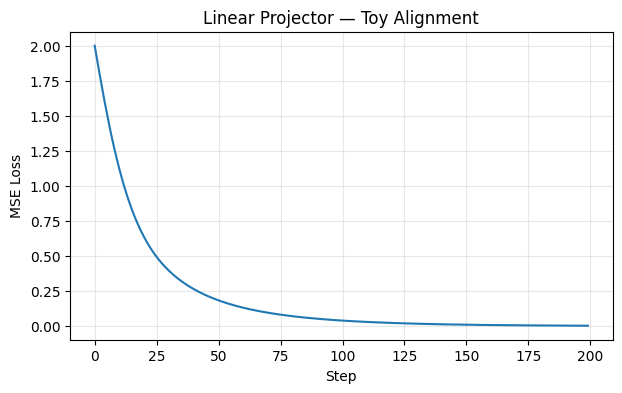

Final loss: 0.0032


In [5]:
torch.manual_seed(42)

projector = LinearProjector(IN_DIM, OUT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(projector.parameters(), lr=1e-3)

# Fixed ground-truth LLM embeddings we want to match
target_llm = torch.randn(BATCH, SEQ, OUT_DIM, device=DEVICE)
clip_features = torch.randn(BATCH, SEQ, IN_DIM, device=DEVICE)

losses = []
for step in range(200):
    pred = projector(clip_features)
    loss = nn.functional.mse_loss(pred, target_llm)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Linear Projector — Toy Alignment")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss: {losses[-1]:.4f}")

## 3. Input vs output distributions

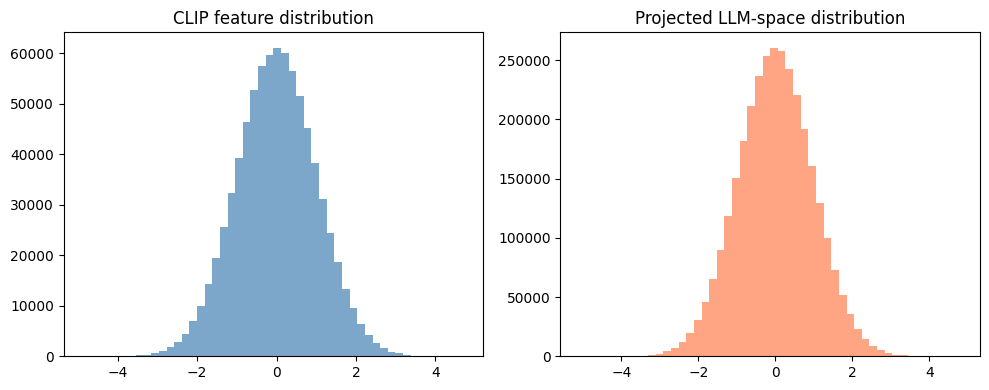

In [6]:
with torch.no_grad():
    projected = projector(clip_features).cpu().flatten()
    inputs = clip_features.cpu().flatten()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(inputs.numpy(), bins=50, alpha=0.7, color="steelblue")
axes[0].set_title("CLIP feature distribution")
axes[1].hist(projected.numpy(), bins=50, alpha=0.7, color="coral")
axes[1].set_title("Projected LLM-space distribution")
plt.tight_layout()
plt.show()

## 4. Gradient check

In [7]:
assert projector.linear.weight.grad is not None
print("Gradients flow through LinearProjector ✓")
print(f"Weight shape: {projector.linear.weight.shape}  → [{OUT_DIM}, {IN_DIM}]")

Gradients flow through LinearProjector ✓
Weight shape: torch.Size([4096, 1024])  → [4096, 1024]


## ✅ Checklist

- [ ] Linear map preserves sequence length: `[B, seq, 1024] → [B, seq, 4096]`
- [ ] Loss decreases on toy alignment
- [ ] `src/projectors/linear_projector.py` is the production version

**Next:** `NB-04-mlp-projector.ipynb`